<a href="https://colab.research.google.com/github/drksnip/A/blob/NSGA-Integration/NSGASearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Boring Bar — GA-Driven Multi-Objective Optimization
=====================================================
Replaces the fixed grid sweep and Den Hartog + scalar refinement of v5
with two nested Genetic Algorithms:

OUTER GA  (NSGA-II style, multi-objective):
  Chromosome:  x = [D_cav, L_cav, D_abs, L_abs]   (4 real-valued genes)
  Objectives:  f1 = -alim_mean    (minimise → maximise alim)
               f2 = -K_static     (minimise → maximise stiffness)
               f3 =  mass_total   (minimise)
  Constraints: • V_abs ≤ 0.70 * V_cav
               • D_abs ≤ D_cav
               • L_abs ≤ L_cav
               • z_cav = L_total - Z_TIP - L_cav  ≥  L1+L2+5mm
               • D_cav wall ≥ 3mm  →  D_cav ≤ D_main - 6mm
  Selection:   Binary tournament on Pareto rank + crowding distance
  Crossover:   Simulated Binary Crossover (SBX, ηc=15)
  Mutation:    Polynomial mutation (ηm=20), prob = 1/n_vars

INNER GA  (single-objective, minimise -alim):
  Chromosome:  [kd, cd]  (2 real-valued genes, log-scale)
  Evaluates:   mean alim over speed range using modal FRF
  Used for:    tuning absorber spring-damper at each outer-GA evaluation
  Replaces:    Den Hartog + minimize_scalar from v5

Architecture:
  evaluate_individual(x)
    ├─ modal_reduce(D_cav, L_cav)        ← FEM, called once per individual
    ├─ inner_GA_tune_kd_cd(modal, ...)   ← GA finds kd, cd
    ├─ compute_alim_mean(modal, kd, cd)  ← multi-speed FRF
    ├─ static_stiff(D_cav, L_cav)        ← direct FEM solve
    └─ total_mass(...)                   ← body integral + md

All physics functions (xsec, build_MK, modal_reduce, frf, alim_from_FRF,
stability_lobes) are identical to v5 — zero changes.
Only sections 9 (absorber tuning) and 12 (main sweep) are replaced.

GA Parameters:
  Outer: pop=40, generations=30, p_cross=0.9, p_mut=1/4
  Inner: pop=20, generations=15, p_cross=0.9, p_mut=1/2

References:
  Deb et al. (2002) NSGA-II — IEEE Trans. Evol. Comput. 6(2):182-197
  Deb & Goyal (1996) SBX crossover
"""

import numpy as np
from scipy.linalg import eigh
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size':9,'axes.titlesize':9,'axes.labelsize':8.5,
                     'xtick.labelsize':8,'ytick.labelsize':8,
                     'legend.fontsize':7,'figure.dpi':150})

In [ ]:
# ══════════════════════════════════════════════════════════════
# 1. FIXED PARAMETERS  (unchanged from v5)
# ══════════════════════════════════════════════════════════════
E_body   = 280e9
rho_body = 7850.0 * 1.2    # 9420 kg/m³
rho_tc   = 15600.0
zeta_s   = 0.01

L_total = 0.300; D1_out = 0.060; D_main = 0.040
D_body_in1 = D_main * 0.50    # 20 mm
D_body_in3 = D_main * 0.50    # 20 mm
L1 = 0.050; L2 = 0.040; L5_tip = 0.030; Z_TIP = L5_tip

Nt=1; Ktc=2000e6; Krc=800e6; ratio_kr=Krc/Ktc
N_ELEM=60; N_MODES=6

D_cav_min, D_cav_max = 0.010, D_main - 2*0.003   # 10–34 mm
L_cav_min, L_cav_max = 0.020, 0.170
VOL_FRAC_MAX = 0.70

# ── GA hyper-parameters ───────────────────────────────────────
#edited outer pop and newer gen
GA_OUTER_POP   = 20     # population size,  outer NSGA-II
GA_OUTER_NGEN  = 10     # number of generations, outer
GA_OUTER_PC    = 0.90   # crossover probability, outer
GA_OUTER_PM    = 1/4    # mutation probability per gene (= 1/n_vars)
GA_OUTER_ETA_C = 15.0   # SBX distribution index (crossover)
GA_OUTER_ETA_M = 20.0   # polynomial mutation distribution index

#Edited newer gen
GA_INNER_POP   = 20     # population size,  inner kd/cd tuner
GA_INNER_NGEN  = 5     # generations, inner
GA_INNER_PC    = 0.90
GA_INNER_PM    = 1/2    # mutation prob per gene (= 1/n_vars_inner)
GA_INNER_ETA_C = 10.0
GA_INNER_ETA_M = 15.0

# kd, cd search bounds (log10 scale for inner GA)
LOG_KD_MIN, LOG_KD_MAX = 4.0, 9.0    # 10⁴–10⁹ N/m
LOG_CD_MIN, LOG_CD_MAX = 0.0, 4.5    # 1–31623 Ns/m

print("="*62)
print("Boring Bar GA — Outer NSGA-II + Inner GA for kd/cd tuning")
print("="*62)
print(f"  Outer GA:  pop={GA_OUTER_POP}  gen={GA_OUTER_NGEN}  "
      f"SBX ηc={GA_OUTER_ETA_C}  poly-mut ηm={GA_OUTER_ETA_M}")
print(f"  Inner GA:  pop={GA_INNER_POP}  gen={GA_INNER_NGEN}  "
      f"(replaces Den Hartog + scalar search)")
print(f"  Variables: D_cav, L_cav, D_abs, L_abs | Objectives: alim↑ K↑ m↓")
print(f"  Constraint: V_abs ≤ {VOL_FRAC_MAX*100:.0f}% V_cav  |  "
      f"D_abs≤D_cav  L_abs≤L_cav  wall≥3mm")
print("="*62)

Boring Bar GA — Outer NSGA-II + Inner GA for kd/cd tuning
  Outer GA:  pop=20  gen=10  SBX ηc=15.0  poly-mut ηm=20.0
  Inner GA:  pop=20  gen=5  (replaces Den Hartog + scalar search)
  Variables: D_cav, L_cav, D_abs, L_abs | Objectives: alim↑ K↑ m↓
  Constraint: V_abs ≤ 70% V_cav  |  D_abs≤D_cav  L_abs≤L_cav  wall≥3mm


In [ ]:
# ══════════════════════════════════════════════════════════════
# 2. CROSS-SECTION  (identical to v5)
# ══════════════════════════════════════════════════════════════
def xsec(z, D_cav, L_cav):
    z_cav = L_total - Z_TIP - L_cav
    z2 = L1+L2; z4 = z_cav+L_cav
    if   z < L1:  Ro = D1_out/2
    elif z < z2:  Ro = D1_out/2 + (z-L1)/L2*(D_main-D1_out)/2
    else:         Ro = D_main/2
    if z < z_cav:
        Ri = D_body_in3/2
    elif z < z4:
        Ri = D_cav/2
    else:
        Ri = 0.0
    Ri = np.clip(Ri, 0.0, Ro-1e-4)
    A  = np.pi*(Ro**2 - Ri**2)
    I  = np.pi*(Ro**4 - Ri**4)/4
    Ip = np.pi*(Ro**4 - Ri**4)/2
    return A, I, Ip, rho_body*A, rho_body*I, rho_body*Ip

In [ ]:
# ══════════════════════════════════════════════════════════════
# 3. FEM  (identical to v5)
# ══════════════════════════════════════════════════════════════
gp = np.array([-np.sqrt(3/5), 0.0, np.sqrt(3/5)])
gw = np.array([5/9, 8/9, 5/9])

def build_MK(D_cav, L_cav):
    ne=N_ELEM; nn=ne+1; le=L_total/ne
    zn=np.linspace(0,L_total,nn); dof=2*nn
    Mg=np.zeros((dof,dof)); Kg=np.zeros((dof,dof)); Gg=np.zeros((dof,dof))
    for e in range(ne):
        za=zn[e]; Ke=np.zeros((4,4)); Me=np.zeros((4,4)); Ge=np.zeros((4,4))
        for g,w in zip(gp,gw):
            xi=(g+1)/2; zg=za+xi*le
            _,Ig,Ipg,rhoAg,rhoIg,rhoIpg = xsec(zg, D_cav, L_cav)
            N1=1-3*xi**2+2*xi**3;  N2=le*(xi-2*xi**2+xi**3)
            N3=3*xi**2-2*xi**3;    N4=le*(-xi**2+xi**3)
            dN1=(-6*xi+6*xi**2)/le;  dN2=1-4*xi+3*xi**2
            dN3=(6*xi-6*xi**2)/le;   dN4=-2*xi+3*xi**2
            d2N1=(-6+12*xi)/le**2;   d2N2=(-4+6*xi)/le
            d2N3=(6-12*xi)/le**2;    d2N4=(-2+6*xi)/le
            Nv  = np.array([N1,N2,N3,N4])
            dN_ = np.array([dN1,dN2,dN3,dN4])
            d2N = np.array([d2N1,d2N2,d2N3,d2N4])
            fac = le*w/2
            Ke += E_body*Ig*np.outer(d2N,d2N)*fac
            Me += (rhoAg*np.outer(Nv,Nv) + rhoIg*np.outer(dN_,dN_))*fac
            Ge += rhoIpg*np.outer(dN_,dN_)*fac
        idx=[2*e,2*e+1,2*(e+1),2*(e+1)+1]
        for i,ii in enumerate(idx):
            for j,jj in enumerate(idx):
                Mg[ii,jj]+=Me[i,j]; Kg[ii,jj]+=Ke[i,j]; Gg[ii,jj]+=Ge[i,j]
    free=list(range(2,dof)); sl=np.ix_(free,free)
    return Mg[sl], Kg[sl], Gg[sl], Mg[sl]

In [ ]:
# ══════════════════════════════════════════════════════════════
# 4. MODAL REDUCTION  (identical to v5)
# ══════════════════════════════════════════════════════════════
def modal_reduce(D_cav, L_cav):
    Mf,Kf,Gf,Mcf = build_MK(D_cav, L_cav)
    evals,evecs   = eigh(Kf, Mf, subset_by_index=[0,N_MODES-1])
    wn  = np.sqrt(np.maximum(evals, 0))
    sc  = np.sqrt(np.diag(evecs.T @ Mf @ evecs))
    Phi = evecs / sc
    return dict(wn=wn, Phi=Phi,
                Gm=Phi.T@Gf@Phi, Mcm=Phi.T@Mcf@Phi,
                tip=Phi[2*(N_ELEM-1),:], Cm=2*zeta_s*wn,
                Mf=Mf, Kf=Kf)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 5. ABSORBER PARAMETERS  (identical to v5)
# ══════════════════════════════════════════════════════════════
def absorber_params(D_cav, L_cav, D_abs, L_abs):
    md    = rho_tc * np.pi*(D_abs/2)**2 * L_abs
    z_cav = L_total - Z_TIP - L_cav
    z_d   = z_cav + L_cav/2
    return md, z_d

def vol_fraction(D_cav, L_cav, D_abs, L_abs):
    V_abs = np.pi*(D_abs/2)**2 * L_abs
    V_cav = np.pi*(D_cav/2)**2 * L_cav
    return V_abs / (V_cav + 1e-20)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6. MODAL FRF  (identical to v5)
# ══════════════════════════════════════════════════════════════
def frf(modal, freqs_hz, Omega, D_cav, L_cav, D_abs, L_abs, kd=0.0, cd=0.0):
    N=N_MODES; wn=modal['wn']; tip=modal['tip']
    Gm=modal['Gm']; Cm_d=modal['Cm']
    Km_eff = np.diag(wn**2) - Omega**2*modal['Mcm']
    md, z_d = absorber_params(D_cav, L_cav, D_abs, L_abs)
    nd  = int(round(z_d/L_total*N_ELEM)); nd=min(nd,N_ELEM)
    iab = min(2*(nd-1) if nd>0 else 0, modal['Phi'].shape[0]-1)
    Phi_d = modal['Phi'][iab,:]
    n2=2*N; use_abs=(kd>0); na=n2+2 if use_abs else n2
    Hxx=np.zeros(len(freqs_hz),dtype=complex)
    Hxy=np.zeros(len(freqs_hz),dtype=complex)
    for k,f in enumerate(freqs_hz):
        w=2*np.pi*f; w2=w**2
        Z=np.zeros((na,na),dtype=complex)
        for r in range(N):
            d=-w2+1j*w*Cm_d[r]+Km_eff[r,r]
            Z[r,r]=d; Z[N+r,N+r]=d
        Z[:N,  N:n2] +=  2j*w*Omega*Gm
        Z[N:n2, :N ] += -2j*w*Omega*Gm
        if use_abs:
            for r in range(N):
                c=(kd+1j*w*cd)*Phi_d[r]
                Z[r,r]     += Phi_d[r]*c; Z[r,  n2]   -= c; Z[n2,   r]   -= c
                Z[N+r,N+r] += Phi_d[r]*c; Z[N+r,n2+1] -= c; Z[n2+1,N+r] -= c
            Z[n2,  n2  ] = -w2*md + kd - Omega**2*md + 1j*w*cd
            Z[n2+1,n2+1] = -w2*md + kd - Omega**2*md + 1j*w*cd
            Z[n2,  n2+1] =  2j*w*Omega*md
            Z[n2+1,n2  ] = -2j*w*Omega*md
        fx=np.zeros(na,dtype=complex); fx[:N]=tip
        fy=np.zeros(na,dtype=complex); fy[N:n2]=tip
        try:
            sol=np.linalg.solve(Z, np.column_stack([fx,fy]))
            Hxx[k]=tip@sol[:N,0]; Hxy[k]=tip@sol[:N,1]
        except: pass
    return Hxx, Hxy

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7. DIRECTIONAL COEFFICIENTS  (identical to v5)
# ══════════════════════════════════════════════════════════════
_phi = np.linspace(0,2*np.pi,100000)
axx_b=np.trapezoid(np.sin(_phi)*(-np.cos(_phi)-ratio_kr*np.sin(_phi)),_phi)/(2*np.pi)
axy_b=np.trapezoid(np.cos(_phi)*(-np.cos(_phi)-ratio_kr*np.sin(_phi)),_phi)/(2*np.pi)
ayx_b=np.trapezoid(np.sin(_phi)*( np.sin(_phi)-ratio_kr*np.cos(_phi)),_phi)/(2*np.pi)
ayy_b=np.trapezoid(np.cos(_phi)*( np.sin(_phi)-ratio_kr*np.cos(_phi)),_phi)/(2*np.pi)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8. STABILITY LIMIT  (identical to v5)
# ══════════════════════════════════════════════════════════════
def alim_from_FRF(Hxx, Hxy):
    best = np.inf
    for k in range(len(Hxx)):
        Hyy=Hxx[k]; Hyx=Hxy[k]
        h11=axx_b*Hxx[k]+axy_b*Hyx; h12=axx_b*Hxy[k]+axy_b*Hyy
        h21=ayx_b*Hxx[k]+ayy_b*Hyx; h22=ayx_b*Hxy[k]+ayy_b*Hyy
        tr=h11+h22; det=h11*h22-h12*h21
        if abs(det)<1e-28: continue
        sq=np.sqrt(tr**2-4*det+0j)
        for lam in [(-tr+sq)/(2*det), (-tr-sq)/(2*det)]:
            rl=np.real(lam)
            if rl<0:
                kap=np.imag(lam)/(rl+1e-30)
                al=(-2*np.pi*rl/(Nt*Ktc))*(1+kap**2)
                if 0<al<best: best=al
    return min(best,0.005) if best<np.inf else 0.0

In [ ]:
# ══════════════════════════════════════════════════════════════
# 9. STATIC STIFFNESS + TOTAL MASS  (identical to v5)
# ══════════════════════════════════════════════════════════════
def static_stiff(D_cav, L_cav):
    _,Kf,_,_ = build_MK(D_cav, L_cav)
    tip_dof   = 2*(N_ELEM-1)
    fv = np.zeros(Kf.shape[0]); fv[tip_dof] = 1.0
    return 1.0 / np.linalg.solve(Kf, fv)[tip_dof]

def total_mass(D_cav, L_cav, D_abs, L_abs):
    zz = np.linspace(0, L_total, 2001); dz = L_total/2000
    mb = sum(rho_body*xsec(z,D_cav,L_cav)[0]*dz for z in (zz[:-1]+zz[1:])/2)
    md,_ = absorber_params(D_cav, L_cav, D_abs, L_abs)
    return mb + md

In [ ]:
# ══════════════════════════════════════════════════════════════
# 10. STABILITY LOBE DIAGRAM  (identical to v5)
# ══════════════════════════════════════════════════════════════
def stability_lobes(modal, D_cav, L_cav, D_abs, L_abs, kd, cd, rpm_max=6000):
    freqs_c = np.linspace(10, 800, 300)

    speeds=[]; depths=[]
    for k,fc in enumerate(freqs_c):
        omegas = 2*np.pi*fc
        Hxx,Hxy = frf(modal, freqs_c, omegas, D_cav, L_cav, D_abs, L_abs, kd, cd)
        Hyy=Hxx[k]; Hyx=Hxy[k]
        h11=axx_b*Hxx[k]+axy_b*Hyx; h12=axx_b*Hxy[k]+axy_b*Hyy
        h21=ayx_b*Hxx[k]+ayy_b*Hyx; h22=ayx_b*Hxy[k]+ayy_b*Hyy
        tr=h11+h22; det=h11*h22-h12*h21
        if abs(det)<1e-28: continue
        sq=np.sqrt(tr**2-4*det+0j)
        for lam in [(-tr+sq)/(2*det), (-tr-sq)/(2*det)]:
            rl=np.real(lam); il=np.imag(lam)
            if rl>=0: continue
            kap=il/(rl+1e-30)
            al=(-2*np.pi*rl/(Nt*Ktc))*(1+kap**2)
            if al<=0 or al>25: continue
            psi=np.arctan2(il,rl)
            for n in range(8):
                eps=np.pi-2*psi if psi<0 else -(np.pi+2*psi)
                T=(eps+2*np.pi*n)/(2*np.pi*fc)
                if T<=0: continue
                rpm=60/T
                if 0<rpm<=rpm_max:
                    speeds.append(rpm); depths.append(al*1e3)
    return np.array(speeds), np.array(depths)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 11. SHARED GA OPERATORS
#     SBX crossover and polynomial mutation used by both
#     the inner and outer GA.
# ══════════════════════════════════════════════════════════════

def sbx_crossover(p1, p2, bounds, eta_c, p_cross, rng):
    """
    Simulated Binary Crossover (SBX) — Deb & Agrawal 1995.

    Parameters
    ----------
    p1, p2   : 1-D arrays, parent chromosomes
    bounds   : (n,2) array of [lo, hi] per gene
    eta_c    : distribution index (larger = closer to parents)
    p_cross  : probability of crossover occurring
    rng      : np.random.Generator

    Returns
    -------
    c1, c2   : 1-D arrays, offspring chromosomes (clipped to bounds)

    How it works
    ------------
    For each gene pair (y1,y2) where y1 ≤ y2:
      u  ~ Uniform(0,1)
      β  = 1 + 2*min(y1-lo, hi-y2)/(y2-y1)   (spread factor)
      α  = 2 - β^(-(ηc+1))
      if u ≤ 1/α:  βq = (u*α)^(1/(ηc+1))
      else:         βq = (1/(2-u*α))^(1/(ηc+1))
      c1 = 0.5*(y1+y2) - 0.5*βq*(y2-y1)
      c2 = 0.5*(y1+y2) + 0.5*βq*(y2-y1)
    Genes where |y2-y1|<ε are inherited unchanged.
    """
    n    = len(p1)
    c1   = p1.copy(); c2 = p2.copy()
    lo   = bounds[:,0]; hi = bounds[:,1]

    if rng.random() > p_cross:
        return c1, c2

    for i in range(n):
        y1 = min(p1[i], p2[i]); y2 = max(p1[i], p2[i])
        if (y2 - y1) < 1e-14:
            continue
        u   = rng.random()
        beta = 1.0 + 2.0*min(y1 - lo[i], hi[i] - y2) / (y2 - y1)
        alpha = 2.0 - beta**(-(eta_c+1.0))
        if u <= 1.0/alpha:
            betaq = (u*alpha)**(1.0/(eta_c+1.0))
        else:
            betaq = (1.0/(2.0 - u*alpha))**(1.0/(eta_c+1.0))
        c1[i] = 0.5*(y1+y2) - 0.5*betaq*(y2-y1)
        c2[i] = 0.5*(y1+y2) + 0.5*betaq*(y2-y1)

    c1 = np.clip(c1, lo, hi); c2 = np.clip(c2, lo, hi)
    return c1, c2


def polynomial_mutation(x, bounds, eta_m, p_mut, rng):
    """
    Polynomial Mutation — Deb & Goyal 1996.

    Parameters
    ----------
    x      : 1-D array, chromosome to mutate (modified in place)
    bounds : (n,2) array
    eta_m  : distribution index (larger = smaller perturbation)
    p_mut  : probability of mutating each gene
    rng    : np.random.Generator

    Returns
    -------
    x_mut  : mutated copy

    How it works
    ------------
    For each gene xi with probability p_mut:
      u ~ Uniform(0,1)
      delta = min(xi-lo, hi-xi)/(hi-lo)
      if u < 0.5:
        deltaq = (2u + (1-2u)*(1-delta)^(ηm+1))^(1/(ηm+1)) - 1
      else:
        deltaq = 1 - (2(1-u) + 2(u-0.5)*(1-delta)^(ηm+1))^(1/(ηm+1))
      xi_new = xi + deltaq*(hi-lo)
    """
    x_mut = x.copy()
    lo    = bounds[:,0]; hi = bounds[:,1]
    for i in range(len(x)):
        if rng.random() > p_mut:
            continue
        u  = rng.random()
        d  = min(x[i]-lo[i], hi[i]-x[i]) / max(hi[i]-lo[i], 1e-14)
        if u < 0.5:
            deltaq = (2.0*u + (1.0-2.0*u)*(1.0-d)**(eta_m+1))**(1.0/(eta_m+1)) - 1.0
        else:
            deltaq = 1.0 - (2.0*(1.0-u) + 2.0*(u-0.5)*(1.0-d)**(eta_m+1))**(1.0/(eta_m+1))
        x_mut[i] = np.clip(x[i] + deltaq*(hi[i]-lo[i]), lo[i], hi[i])
    return x_mut


def tournament_select(pop, fitness, rng, k=2):
    """
    Binary tournament selection.
    Selects one individual: draw k candidates, return the one with
    lowest fitness (minimisation convention).

    Parameters
    ----------
    pop     : (N, n_vars) array
    fitness : (N,) array, scalar fitness (lower = better)
    k       : tournament size (default 2)
    rng     : np.random.Generator
    """
    idx = rng.choice(len(pop), size=k, replace=False)
    winner = idx[np.argmin(fitness[idx])]
    return pop[winner].copy()

In [ ]:
# ══════════════════════════════════════════════════════════════
# 12. INNER GA — optimise kd and cd
#
#  Purpose: replace the Den Hartog + minimize_scalar chain from v5
#  with a GA that searches [log10(kd), log10(cd)] jointly.
#
#  Chromosome: [lkd, lcd]  where lkd = log10(kd), lcd = log10(cd)
#  Fitness:    f = -alim_mean  (scalar, single-objective, minimise)
#              alim_mean evaluated at 3 representative speeds:
#              0, 3000, 6000 RPM (fast; enough to capture speed effect)
#
#  Population initialisation:
#    Half of initial population seeded with Den Hartog estimate
#    (ensures a good prior while GA explores globally)
#
#  Returns: kd_opt, cd_opt
# ══════════════════════════════════════════════════════════════

# Frequency and speed arrays used inside inner GA (compact for speed)
_FREQS_INNER = np.linspace(10, 800, 100)
_OMS_INNER   = np.array([0.0, 3000.0, 6000.0]) * 2*np.pi/60
_BOUNDS_INNER = np.array([[LOG_KD_MIN, LOG_KD_MAX],
                           [LOG_CD_MIN, LOG_CD_MAX]])

def _inner_fitness(lkd, lcd, modal, D_cav, L_cav, D_abs, L_abs):
    """
    Scalar fitness for inner GA: negative mean alim across speeds.
    Bare-bar floor prevents numerical inflation.
    """
    kd_ = 10**lkd; cd_ = 10**lcd
    total = 0.0
    for Om in _OMS_INNER:
        Ha, Hxa = frf(modal, _FREQS_INNER, Om, D_cav, L_cav, D_abs, L_abs, kd_, cd_)
        Hb, Hxb = frf(modal, _FREQS_INNER, Om, D_cav, L_cav, D_abs, L_abs, 0.0, 0.0)

        a = alim_from_FRF(Ha, Hxa)
        b = alim_from_FRF(Hb, Hxb)
        total += max(min(a, b*50.0), b)
    return -total / len(_OMS_INNER)


def inner_GA_tune_kd_cd(modal, D_cav, L_cav, D_abs, L_abs, rng):
    """
    Inner GA: evolve [log10(kd), log10(cd)] to maximise alim_mean.

    Initialisation
    --------------
    • Den Hartog estimate provides kd_dh, cd_dh.
    • First GA_INNER_POP//2 individuals are seeded around [log10(kd_dh),
      log10(cd_dh)] with Gaussian jitter (σ=0.3 decades).
    • Remaining individuals are random within bounds.
    This warm-start ensures the GA never starts far from a known good
    solution, reducing generations needed for convergence.

    Evolution
    ---------
    Each generation:
      1. Evaluate fitness for entire population.
      2. Elitism: copy best individual directly to next generation.
      3. Fill rest of next generation via:
           a. Binary tournament selection of two parents.
           b. SBX crossover with probability GA_INNER_PC.
           c. Polynomial mutation with probability GA_INNER_PM per gene.
      4. Evaluate offspring, replace population.

    Returns
    -------
    kd_opt, cd_opt  : floats (actual N/m and Ns/m values)
    """
    # ── Den Hartog warm-start ──────────────────────────────────
    md, _ = absorber_params(D_cav, L_cav, D_abs, L_abs)
    wn1   = modal['wn'][0]
    mu    = max(md / (rho_body*np.pi*(D_main/2)**2*L_total), 0.005)
    wd    = wn1/(1+mu)
    kd_dh = md*wd**2
    cd_dh = 2*np.sqrt(3*mu/(8*(1+mu)**3))*md*wd
    lkd_dh = np.log10(max(kd_dh, 10**LOG_KD_MIN))
    lcd_dh = np.log10(max(cd_dh, 10**LOG_CD_MIN))

    n_pop  = GA_INNER_POP
    n_half = n_pop // 2
    bounds = _BOUNDS_INNER
    lo = bounds[:,0]; hi = bounds[:,1]

    # Initialise population
    pop = np.zeros((n_pop, 2))
    # Warm half: jitter around Den Hartog
    pop[:n_half, 0] = np.clip(lkd_dh + rng.normal(0, 0.3, n_half), lo[0], hi[0])
    pop[:n_half, 1] = np.clip(lcd_dh + rng.normal(0, 0.3, n_half), lo[1], hi[1])
    # Random half: uniform in bounds
    pop[n_half:, 0] = rng.uniform(lo[0], hi[0], n_pop-n_half)
    pop[n_half:, 1] = rng.uniform(lo[1], hi[1], n_pop-n_half)

    # Evaluate initial fitness
    fit = np.array([_inner_fitness(p[0],p[1], modal, D_cav, L_cav, D_abs, L_abs)
                    for p in pop])

    for _gen in range(GA_INNER_NGEN):
        new_pop = np.zeros_like(pop)
        # Elitism: preserve best
        i_elite = np.argmin(fit)
        new_pop[0] = pop[i_elite]
        # Fill rest
        child_idx = 1
        while child_idx < n_pop:
            p1 = tournament_select(pop, fit, rng)
            p2 = tournament_select(pop, fit, rng)
            c1, c2 = sbx_crossover(p1, p2, bounds, GA_INNER_ETA_C, GA_INNER_PC, rng)
            c1 = polynomial_mutation(c1, bounds, GA_INNER_ETA_M, GA_INNER_PM, rng)
            c2 = polynomial_mutation(c2, bounds, GA_INNER_ETA_M, GA_INNER_PM, rng)
            new_pop[child_idx] = c1
            if child_idx+1 < n_pop:
                new_pop[child_idx+1] = c2
            child_idx += 2
        pop = new_pop
        fit = np.array([_inner_fitness(p[0],p[1], modal, D_cav, L_cav, D_abs, L_abs)
                        for p in pop])

    i_best_inner = np.argmin(fit)
    kd_opt = 10**pop[i_best_inner, 0]
    cd_opt = 10**pop[i_best_inner, 1]
    return kd_opt, cd_opt

In [ ]:
# ══════════════════════════════════════════════════════════════
# 13. FEASIBILITY CHECK + CONSTRAINT REPAIR
#
#  Called by the outer GA before evaluating any individual.
#  Genes outside bounds are clipped.  Constraint violations are
#  repaired by scaling down D_abs or L_abs to the feasible boundary.
#  A chromosome that cannot be made feasible returns None (penalised).
# ══════════════════════════════════════════════════════════════

# Outer GA bounds: [D_cav, L_cav, D_abs, L_abs]  all in metres
_BOUNDS_OUTER = np.array([
    [D_cav_min,  D_cav_max],   # D_cav
    [L_cav_min,  L_cav_max],   # L_cav
    [0.005,      D_cav_max-0.001],   # D_abs  (upper will be enforced to ≤ D_cav)
    [0.005,      L_cav_max-0.001],   # L_abs  (upper will be enforced to ≤ L_cav)
])

def repair_and_check(x):
    """
    Repair a 4-gene outer-GA chromosome [D_cav, L_cav, D_abs, L_abs]:
      1. Clip all genes to their hard bounds.
      2. Enforce D_abs ≤ D_cav  (clip D_abs).
      3. Enforce L_abs ≤ L_cav  (clip L_abs).
      4. Enforce V_abs ≤ VOL_FRAC_MAX * V_cav by scaling L_abs down.
      5. Enforce z_cav ≥ L1+L2+5mm  (cavity must sit after the taper).
      6. Check structural feasibility (minimum absorber size).

    Returns repaired x, or None if infeasible after repair.
    """
    x = np.clip(x, _BOUNDS_OUTER[:,0], _BOUNDS_OUTER[:,1])
    D_cav, L_cav, D_abs, L_abs = x

    # Enforce cavity starts after taper
    z_cav = L_total - Z_TIP - L_cav
    if z_cav < L1+L2+0.005:
        # Shorten L_cav until z_cav is valid
        L_cav = L_total - Z_TIP - (L1+L2+0.005)
        if L_cav < L_cav_min:
            return None   # cannot be repaired
        x[1] = L_cav

    # Enforce D_abs ≤ D_cav
    D_abs = min(D_abs, D_cav)
    x[2]  = D_abs

    # Enforce L_abs ≤ L_cav
    L_abs = min(L_abs, L_cav)
    x[3]  = L_abs

    # Enforce volume fraction ≤ VOL_FRAC_MAX
    V_cav = np.pi*(D_cav/2)**2 * L_cav
    V_abs = np.pi*(D_abs/2)**2 * L_abs
    if V_abs > VOL_FRAC_MAX * V_cav:
        # Scale L_abs down to exactly VOL_FRAC_MAX
        L_abs = VOL_FRAC_MAX * (D_cav/D_abs)**2 * L_cav
        L_abs = min(L_abs, L_cav)
        x[3]  = L_abs

    # Reject if absorber is too small to be meaningful
    if D_abs < 0.005 or L_abs < 0.005:
        return None

    return x

In [ ]:
# ══════════════════════════════════════════════════════════════
# 14. OUTER GA INDIVIDUAL EVALUATION
#
#  evaluate_individual(x) is the single point of contact between
#  the outer GA and the physics model.  It:
#    1. Repairs the chromosome.
#    2. Builds the FEM modal model for the cavity geometry.
#    3. Calls inner_GA_tune_kd_cd to find optimal kd, cd.
#    4. Computes the three objective values.
#  Returns a dict with all results, or None for infeasible x.
# ══════════════════════════════════════════════════════════════

_FREQS_OUTER = np.linspace(10, 800, 120)    # FRF resolution for outer eval
_OMS_OUTER   = np.linspace(0, 6000, 5)*2*np.pi/60   # speed sweep for alim

def evaluate_individual(x, rng):
    """
    Full physics evaluation of one outer-GA chromosome.

    Parameters
    ----------
    x   : [D_cav, L_cav, D_abs, L_abs]  (metres)
    rng : np.random.Generator (passed in so inner GA is reproducible
          when seeded from outer GA generation counter)

    Returns
    -------
    dict with keys:
      x, D_cav, L_cav, D_abs, L_abs, kd, cd, md,
      alim [mm], stiff [MN/m], mass [g], vf, fn1 [Hz]
    or None if infeasible.
    """
    x = repair_and_check(x)
    if x is None:
        return None
    D_cav, L_cav, D_abs, L_abs = x

    # FEM + modal (expensive, done once per individual)
    modal = modal_reduce(D_cav, L_cav)

    # Inner GA: find optimal kd, cd for this geometry
    kd, cd = inner_GA_tune_kd_cd(modal, D_cav, L_cav, D_abs, L_abs, rng)

    # Objective 1: mean alim over speed range
    alims = []
    for Om in _OMS_OUTER:
        Ha,Hxa = frf(modal, _FREQS_OUTER, Om, D_cav, L_cav, D_abs, L_abs, kd, cd)
        Hb,Hxb = frf(modal, _FREQS_OUTER, Om, D_cav, L_cav, D_abs, L_abs, 0.0, 0.0)
        a = alim_from_FRF(Ha, Hxa)*1e3
        b = alim_from_FRF(Hb, Hxb)*1e3
        alims.append(max(min(a, b*50.0), b))
    alim_mean = float(np.mean(alims))

    # Objective 2: static tip stiffness
    K_tip = static_stiff(D_cav, L_cav)

    # Objective 3: total mass
    m_tot = total_mass(D_cav, L_cav, D_abs, L_abs)

    md, _ = absorber_params(D_cav, L_cav, D_abs, L_abs)
    fn1   = modal['wn'][0]/(2*np.pi)
    vf    = vol_fraction(D_cav, L_cav, D_abs, L_abs)

    return dict(
        x=x.copy(),
        D_cav=D_cav, L_cav=L_cav, D_abs=D_abs, L_abs=L_abs,
        kd=kd, cd=cd, md=md*1e3,             # md in grams
        alim=alim_mean,                        # mm
        stiff=K_tip/1e6,                       # MN/m
        mass=m_tot*1e3,                        # g
        vf=vf, fn1=fn1,
        modal=modal
    )

In [ ]:
# ══════════════════════════════════════════════════════════════
# 15. OUTER NSGA-II  —  MULTI-OBJECTIVE EVOLUTION
#
#  Implements NSGA-II (Deb et al. 2002) for 3 objectives.
#
#  Key steps each generation:
#  ┌─────────────────────────────────────────────────────┐
#  │  Parent population P_t  (size N)                   │
#  │    ↓  binary tournament + SBX + poly-mutation       │
#  │  Offspring population Q_t  (size N)                 │
#  │    ↓  combine → R_t = P_t ∪ Q_t  (size 2N)         │
#  │    ↓  non-dominated sort → fronts F1, F2, ...       │
#  │    ↓  crowding distance within each front           │
#  │    ↓  select best N by (rank, crowding desc)        │
#  │  New population P_{t+1}  (size N)                   │
#  └─────────────────────────────────────────────────────┘
#
#  Objective vector (minimisation):
#    obj[0] = -alim_mean   (negate to maximise)
#    obj[1] = -K_static    (negate to maximise)
#    obj[2] =  mass_total  (minimise directly)
#
#  Pareto rank:  non_dominated_sort(objs) → rank array
#  Crowding:     crowding_distance(objs_in_front) → distance array
#
#  Selection for reproduction:
#    Binary tournament: individual i beats j if
#      rank[i] < rank[j]  OR  (rank[i]==rank[j] AND crowd[i] > crowd[j])
# ══════════════════════════════════════════════════════════════

def non_dominated_sort(objs):
    """
    Fast non-dominated sort — Deb et al. 2002.

    Parameters
    ----------
    objs : (N, M) array, objective values (all minimise)

    Returns
    -------
    ranks : (N,) int array, Pareto rank of each individual
            (rank 0 = Pareto front, rank 1 = second front, ...)
    fronts: list of lists, fronts[k] = indices of rank-k individuals

    Algorithm
    ---------
    For each individual i:
      S_i = set of individuals i dominates
      n_i = number of individuals that dominate i
    Individual i dominates j if:
      obj[i,k] ≤ obj[j,k] for all k, and
      obj[i,k] < obj[j,k] for at least one k.
    Front 1 = {i : n_i == 0}.
    Subsequent fronts: reduce n_j for all j ∈ S_i, add to next front
    when n_j reaches 0.
    """
    N   = len(objs)
    S   = [[] for _ in range(N)]   # dominated set
    n   = np.zeros(N, dtype=int)   # domination counter
    ranks = np.zeros(N, dtype=int)
    fronts = [[]]

    for i in range(N):
        for j in range(N):
            if i == j: continue
            # Does i dominate j?
            if np.all(objs[i] <= objs[j]) and np.any(objs[i] < objs[j]):
                S[i].append(j)
            # Does j dominate i?
            elif np.all(objs[j] <= objs[i]) and np.any(objs[j] < objs[i]):
                n[i] += 1
        if n[i] == 0:
            ranks[i] = 0
            fronts[0].append(i)

    k = 0
    while fronts[k]:
        next_front = []
        for i in fronts[k]:
            for j in S[i]:
                n[j] -= 1
                if n[j] == 0:
                    ranks[j] = k+1
                    next_front.append(j)
        k += 1
        fronts.append(next_front)
    fronts.pop()  # remove empty last front
    return ranks, fronts

In [ ]:
def crowding_distance(objs_front):
    """
    Crowding distance for individuals in a single front.

    Parameters
    ----------
    objs_front : (n, M) array, objectives of this front only

    Returns
    -------
    dist : (n,) array, crowding distance (∞ for boundary individuals)

    Algorithm
    ---------
    For each objective m:
      Sort individuals by obj_m.
      Assign dist = ∞ to first and last.
      For intermediate: dist += (obj_m[k+1] - obj_m[k-1]) / (obj_m_max - obj_m_min)
    """
    n, M = objs_front.shape
    if n <= 2:
        return np.full(n, np.inf)
    dist = np.zeros(n)
    for m in range(M):
        order  = np.argsort(objs_front[:,m])
        f_min  = objs_front[order[0], m]
        f_max  = objs_front[order[-1],m]
        dist[order[0]]  = np.inf
        dist[order[-1]] = np.inf
        span = f_max - f_min if (f_max - f_min) > 1e-30 else 1e-30
        for k in range(1, n-1):
            dist[order[k]] += (objs_front[order[k+1],m] -
                               objs_front[order[k-1],m]) / span
    return dist


def nsga2_tournament(pop_results, ranks, crowd, rng):
    """
    NSGA-II binary tournament: select one parent from pop_results.
    Winner = lower rank; ties broken by higher crowding distance.
    """
    N   = len(pop_results)
    i,j = rng.choice(N, size=2, replace=False)
    if   ranks[i] < ranks[j]:                    return i
    elif ranks[i] > ranks[j]:                    return j
    elif crowd[i] > crowd[j]:                    return i
    elif crowd[i] < crowd[j]:                    return j
    else:                                         return rng.choice([i,j])


def run_outer_NSGA2(seed=42):
    """
    Run the outer NSGA-II optimisation loop.

    Parameters
    ----------
    seed : int, random seed for reproducibility

    Returns
    -------
    all_results : list of all evaluated individual dicts, across all
                  generations (length ≤ GA_OUTER_POP * (GA_OUTER_NGEN+1))
    pareto_front: list of dicts on the final Pareto front (rank 0)
    history     : dict with per-generation statistics for convergence plots

    Algorithm walkthrough
    ---------------------
    Generation 0:
      • Sample GA_OUTER_POP chromosomes uniformly within bounds.
      • Repair each, evaluate via evaluate_individual.
      • Compute objectives, non-dominated sort, crowding distances.

    Each subsequent generation t = 1 … GA_OUTER_NGEN:
      1. Generate offspring Q_t (same size as P_t):
           For each pair of offspring:
             a. Select two parents via NSGA-II tournament
                (uses rank + crowding from previous generation).
             b. SBX crossover of the two parent chromosomes.
             c. Polynomial mutation on each offspring.
             d. Repair chromosomes; evaluate via evaluate_individual.
      2. Combine: R_t = P_t ∪ Q_t  (2*pop_size evaluated individuals).
      3. Non-dominated sort R_t → ranks, fronts.
      4. Assign crowding distances within each front.
      5. Select best pop_size individuals by (rank asc, crowd desc)
         to form P_{t+1}.
      6. Log statistics: mean/best alim, best stiffness, min mass.

    Progress reporting:
      Prints one line per generation showing best objectives found so far.
    """
    rng = np.random.default_rng(seed)
    bounds = _BOUNDS_OUTER
    lo = bounds[:,0]; hi = bounds[:,1]
    N  = GA_OUTER_POP

    all_results  = []
    history      = dict(gen=[], best_alim=[], best_stiff=[], min_mass=[],
                        n_pareto=[], mean_alim=[])

    # ── Generation 0: initialise ──────────────────────────────
    print(f"\n{'─'*62}")
    print(f"NSGA-II Outer GA  pop={N}  gen={GA_OUTER_NGEN}")
    print(f"{'─'*62}")

    pop_x = rng.uniform(lo, hi, size=(N, 4))   # random initial population
    pop_results = []
    print(f"Gen 0/{GA_OUTER_NGEN} — evaluating {N} individuals...")
    for k in range(N):
        inner_rng = np.random.default_rng(seed + k)
        res = evaluate_individual(pop_x[k], inner_rng)
        if res is None:
            # Replace infeasible with random feasible attempt
            for _retry in range(10):
                x_new = rng.uniform(lo, hi, size=4)
                res = evaluate_individual(x_new, inner_rng)
                if res is not None:
                    break
        pop_results.append(res)
        if res is not None:
            print(f"  [{k+1:2d}/{N}] Dc={res['D_cav']*1e3:.0f}mm "
                  f"Lc={res['L_cav']*1e3:.0f}mm "
                  f"Da={res['D_abs']*1e3:.0f}mm "
                  f"La={res['L_abs']*1e3:.0f}mm → "
                  f"alim={res['alim']:.2f}mm "
                  f"K={res['stiff']:.2f}MN/m "
                  f"m={res['mass']:.0f}g", flush=True)
        else:
            print(f"  [{k+1:2d}/{N}] infeasible", flush=True)

    all_results.extend([r for r in pop_results if r is not None])

    # ── Main NSGA-II loop ─────────────────────────────────────
    for gen in range(1, GA_OUTER_NGEN+1):
        # Build objective matrix from current valid population
        valid_mask = [r is not None for r in pop_results]
        valid_res  = [r for r in pop_results if r is not None]
        objs = np.array([[-r['alim'], -r['stiff'], r['mass']]
                          for r in valid_res])   # shape (n_valid, 3)

        # Non-dominated sort + crowding on valid individuals
        ranks, fronts = non_dominated_sort(objs)
        crowd = np.zeros(len(valid_res))
        for front in fronts:
            if len(front) < 1: continue
            cd = crowding_distance(objs[front])
            for i_local, i_global in enumerate(front):
                crowd[i_global] = cd[i_local]

        # Map valid_res indices back to pop_results indices
        valid_idx = [i for i,r in enumerate(pop_results) if r is not None]

        # Generate offspring
        offspring_results = []
        n_children = 0
        while n_children < N:
            # Select two parents from valid pool
            pi = nsga2_tournament(valid_res, ranks, crowd, rng)
            pj = nsga2_tournament(valid_res, ranks, crowd, rng)
            xp1 = valid_res[pi]['x']
            xp2 = valid_res[pj]['x']

            # SBX crossover
            xc1, xc2 = sbx_crossover(xp1, xp2, bounds,
                                      GA_OUTER_ETA_C, GA_OUTER_PC, rng)
            # Polynomial mutation
            xc1 = polynomial_mutation(xc1, bounds, GA_OUTER_ETA_M, GA_OUTER_PM, rng)
            xc2 = polynomial_mutation(xc2, bounds, GA_OUTER_ETA_M, GA_OUTER_PM, rng)

            for xc in [xc1, xc2]:
                if n_children >= N: break
                inner_rng = np.random.default_rng(seed + gen*1000 + n_children)
                res = evaluate_individual(xc, inner_rng)
                offspring_results.append(res)
                n_children += 1

        # Combine parent + offspring (R_t = P_t ∪ Q_t)
        combined = [r for r in pop_results + offspring_results if r is not None]
        if len(combined) == 0:
            continue   # pathological; skip generation
        objs_combined = np.array([[-r['alim'], -r['stiff'], r['mass']]
                                   for r in combined])

        # Non-dominated sort on combined pool
        ranks_c, fronts_c = non_dominated_sort(objs_combined)
        crowd_c = np.zeros(len(combined))
        for front in fronts_c:
            if len(front) < 1: continue
            cd = crowding_distance(objs_combined[front])
            for i_local, i_global in enumerate(front):
                crowd_c[i_global] = cd[i_local]

        # Select best N by (rank asc, crowding desc)
        sort_key = [(ranks_c[i], -crowd_c[i]) for i in range(len(combined))]
        order    = sorted(range(len(combined)), key=lambda i: sort_key[i])
        selected = order[:N]
        pop_results = [combined[i] for i in selected]

        all_results.extend([r for r in offspring_results if r is not None])

        # Statistics for this generation
        pareto_idx  = [i for i,r in enumerate(combined)
                       if r is not None and ranks_c[i]==0]
        pareto_this = [combined[i] for i in pareto_idx]
        alims_  = [r['alim']  for r in pop_results if r is not None]
        stiffs_ = [r['stiff'] for r in pop_results if r is not None]
        masses_ = [r['mass']  for r in pop_results if r is not None]
        history['gen'].append(gen)
        history['best_alim'].append(max(alims_) if alims_ else 0)
        history['best_stiff'].append(max(stiffs_) if stiffs_ else 0)
        history['min_mass'].append(min(masses_) if masses_ else 0)
        history['n_pareto'].append(len(pareto_this))
        history['mean_alim'].append(np.mean(alims_) if alims_ else 0)

        print(f"Gen {gen:2d}/{GA_OUTER_NGEN} | "
              f"best alim={history['best_alim'][-1]:.2f}mm  "
              f"best K={history['best_stiff'][-1]:.2f}MN/m  "
              f"min m={history['min_mass'][-1]:.0f}g  "
              f"|Pareto|={history['n_pareto'][-1]}",
              flush=True)

    # ── Final Pareto front ────────────────────────────────────
    valid_final = [r for r in pop_results if r is not None]
    objs_final  = np.array([[-r['alim'], -r['stiff'], r['mass']]
                             for r in valid_final])
    ranks_f, fronts_f = non_dominated_sort(objs_final)
    pareto_front = [valid_final[i] for i in range(len(valid_final))
                    if ranks_f[i] == 0]

    return all_results, pareto_front, history

In [ ]:
# ══════════════════════════════════════════════════════════════
# 16. POST-PROCESSING HELPERS
#     Pareto analysis on all_results (identical logic to v5)
# ══════════════════════════════════════════════════════════════

def extract_arrays(results):
    """Extract objective and design variable arrays from results list."""
    a  = np.array([r['alim']  for r in results])
    s  = np.array([r['stiff'] for r in results])
    m  = np.array([r['mass']  for r in results])
    fn = np.array([r['fn1']   for r in results])
    Dc = np.array([r['D_cav'] for r in results])*1e3
    Lc = np.array([r['L_cav'] for r in results])*1e3
    Da = np.array([r['D_abs'] for r in results])*1e3
    La = np.array([r['L_abs'] for r in results])*1e3
    vf = np.array([r['vf']    for r in results])
    kd = np.array([r['kd']    for r in results])
    cd = np.array([r['cd']    for r in results])
    md = np.array([r['md']    for r in results])   # already in g
    return dict(a=a,s=s,m=m,fn=fn,Dc=Dc,Lc=Lc,Da=Da,La=La,
                vf=vf,kd=kd,cd=cd,md=md)


def n01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-30)


def full_pareto(results):
    """Re-compute Pareto front over all_results (complete history)."""
    arr = extract_arrays(results)
    objs = np.column_stack([-arr['a'], -arr['s'], arr['m']])
    ranks, fronts = non_dominated_sort(objs)
    pareto_mask = (ranks == 0)
    score = (n01(arr['a']) + n01(arr['s']) + n01(-arr['m'])) / 3
    i_best  = np.argmax(score)
    i_alim  = np.argmax(arr['a'])
    i_stiff = np.argmax(arr['s'])
    i_mass  = np.argmin(arr['m'])
    i_worst = np.argmin(score)
    return pareto_mask, score, i_best, i_alim, i_stiff, i_mass, i_worst

In [ ]:
# @title
# ══════════════════════════════════════════════════════════════
# 17. PLOTTING  (identical panel layout to v5, plus 2 new panels:
#    convergence history and Pareto rank distribution)
# ══════════════════════════════════════════════════════════════

def make_plots(all_results, pareto_front, history):
    arr = extract_arrays(all_results)
    a_v=arr['a']; s_v=arr['s']; m_v=arr['m']
    Dc_v=arr['Dc']; Lc_v=arr['Lc']; Da_v=arr['Da']; La_v=arr['La']
    vf_v=arr['vf']; kd_v=arr['kd']; cd_v=arr['cd']; md_v=arr['md']

    pareto_mask, score, i_best, i_alim, i_stiff, i_mass, i_worst = \
        full_pareto(all_results)

    BEST_C='#D62728'; PARETO_C='#FF7F0E'
    fig = plt.figure(figsize=(20,24))
    fig.suptitle(
        'Boring Bar — GA-Driven 4-Variable MOO  (NSGA-II + Inner GA for kd/cd)\n'
        f'Outer NSGA-II: pop={GA_OUTER_POP}  gen={GA_OUTER_NGEN}  '
        f'SBX ηc={GA_OUTER_ETA_C}  poly-mut ηm={GA_OUTER_ETA_M}\n'
        f'Inner GA: pop={GA_INNER_POP}  gen={GA_INNER_NGEN}  '
        f'(replaces Den Hartog + scalar search)\n'
        f'5-section WC bar  ·  TC absorber  ·  V_abs≤{VOL_FRAC_MAX*100:.0f}%V_cav  ·  '
        f'Single-point boring Nt=1  ·  '
        f'Objectives: alim↑  K↑  m↓',
        fontsize=10, fontweight='bold', y=0.998)

    gs = gridspec.GridSpec(6, 4, figure=fig, hspace=0.52, wspace=0.38)

    # ── ROW 0 ── Convergence history ─────────────────────────
    if history['gen']:
        ax=fig.add_subplot(gs[0,0])
        ax.plot(history['gen'], history['best_alim'],  'b-o', ms=4, lw=1.5,
                label='Best alim [mm]')
        ax.plot(history['gen'], history['mean_alim'],  'b--',ms=3, lw=1.0,
                label='Mean alim [mm]')
        ax.set_xlabel('Generation'); ax.set_ylabel('alim [mm]')
        ax.set_title('(a) Convergence — stability limit')
        ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

        ax=fig.add_subplot(gs[0,1])
        ax.plot(history['gen'], history['best_stiff'], 'g-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('Best K [MN/m]')
        ax.set_title('(b) Convergence — static stiffness')
        ax.grid(True,alpha=0.3)

        ax=fig.add_subplot(gs[0,2])
        ax.plot(history['gen'], history['min_mass'],   'm-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('Min mass [g]')
        ax.set_title('(c) Convergence — minimum mass')
        ax.grid(True,alpha=0.3)

        ax=fig.add_subplot(gs[0,3])
        ax.plot(history['gen'], history['n_pareto'],   'k-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('|Pareto front|')
        ax.set_title('(d) Pareto front growth per generation')
        ax.grid(True,alpha=0.3)

    # ── ROW 1 ── Objective scatter (coloured by generation order) ─
    gen_label = np.linspace(0,1,len(all_results))  # proxy for generation

    ax=fig.add_subplot(gs[1,0])
    sc=ax.scatter(Dc_v,Lc_v,c=a_v,cmap='RdYlGn',s=15,alpha=0.6)
    ax.scatter(Dc_v[pareto_mask],Lc_v[pareto_mask],s=55,
               edgecolors=PARETO_C,facecolors='none',lw=1.5,zorder=4,label='Pareto')
    ax.scatter(Dc_v[i_best],Lc_v[i_best],s=180,marker='*',
               color=BEST_C,zorder=5,label='Best')
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('alim [mm]',fontsize=7)
    ax.set_xlabel('D_cav [mm]'); ax.set_ylabel('L_cav [mm]')
    ax.set_title('(e) Cavity design space — colour=alim')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[1,1])
    sc=ax.scatter(Da_v,La_v,c=a_v,cmap='RdYlGn',s=15,alpha=0.6)
    ax.scatter(Da_v[pareto_mask],La_v[pareto_mask],s=55,
               edgecolors=PARETO_C,facecolors='none',lw=1.5,zorder=4,label='Pareto')
    ax.scatter(Da_v[i_best],La_v[i_best],s=180,marker='*',
               color=BEST_C,zorder=5,label='Best')
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('alim [mm]',fontsize=7)
    ax.set_xlabel('D_abs [mm]'); ax.set_ylabel('L_abs [mm]')
    ax.set_title('(f) Absorber design space — colour=alim')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[1,2])
    sc=ax.scatter(vf_v*100,a_v,c=Dc_v,cmap='viridis',s=15,alpha=0.7)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('D_cav [mm]',fontsize=7)
    ax.axvline(VOL_FRAC_MAX*100,color='red',ls='--',lw=1.2,
               label=f'{VOL_FRAC_MAX*100:.0f}% limit')
    ax.scatter(vf_v[i_best]*100,a_v[i_best],s=150,marker='*',
               color=BEST_C,zorder=5)
    ax.set_xlabel('Fill fraction φ [%]'); ax.set_ylabel('alim [mm]')
    ax.set_title('(g) Stability vs fill fraction')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[1,3])
    sc=ax.scatter(md_v,a_v,c=vf_v*100,cmap='RdYlGn',s=15,alpha=0.7,
                  vmin=10,vmax=70)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('Fill [%]',fontsize=7)
    ax.scatter(md_v[i_best],a_v[i_best],s=150,marker='*',
               color=BEST_C,zorder=5,
               label=f'Best: md={md_v[i_best]:.0f}g')
    ax.set_xlabel('Absorber mass [g]'); ax.set_ylabel('alim [mm]')
    ax.set_title('(h) alim vs absorber mass')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    # ── ROW 2 ── Pareto projections ───────────────────────────
    for col,(xa,ya,xl,yl,ttl) in enumerate([
        (a_v, s_v, 'alim [mm]',        'Stiffness [MN/m]', '(i) alim vs stiffness'),
        (a_v, m_v, 'alim [mm]',        'Mass [g]',          '(j) alim vs mass'),
        (s_v, m_v, 'Stiffness [MN/m]', 'Mass [g]',          '(k) stiffness vs mass'),
        (a_v*s_v,  m_v,'alim×K',       'Mass [g]',          '(l) combined product'),
    ]):
        ax=fig.add_subplot(gs[2,col])
        sc=ax.scatter(xa,ya,c=score,cmap='RdYlGn',s=10,alpha=0.5,vmin=0,vmax=1)
        ax.scatter(xa[pareto_mask],ya[pareto_mask],s=55,edgecolors=PARETO_C,
                   facecolors='none',lw=1.5,zorder=4,
                   label=f'Pareto ({pareto_mask.sum()})')
        ax.scatter(xa[i_best],ya[i_best],s=200,marker='*',
                   c=BEST_C,zorder=5,
                   label=f'Best\n({Dc_v[i_best]:.0f},{Lc_v[i_best]:.0f}mm)\n'
                         f'({Da_v[i_best]:.0f},{La_v[i_best]:.0f}mm)')
        plt.colorbar(sc,ax=ax,shrink=0.8).set_label('Score',fontsize=7)
        ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl)
        ax.legend(fontsize=6); ax.grid(True,alpha=0.3)

    # ── ROW 3 ── kd/cd landscape from inner GA ────────────────
    ax=fig.add_subplot(gs[3,0])
    sc=ax.scatter(np.log10(kd_v),np.log10(cd_v),c=a_v,
                  cmap='RdYlGn',s=15,alpha=0.7)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('alim [mm]',fontsize=7)
    ax.scatter(np.log10(kd_v[i_best]),np.log10(cd_v[i_best]),
               s=180,marker='*',color=BEST_C,zorder=5,
               label=f'Best kd={kd_v[i_best]:.2e}\ncd={cd_v[i_best]:.0f}')
    ax.set_xlabel('log10(kd) [N/m]'); ax.set_ylabel('log10(cd) [Ns/m]')
    ax.set_title('(m) Inner GA result: kd vs cd landscape\n(all evaluated designs)')
    ax.legend(fontsize=6.5); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[3,1])
    sc=ax.scatter(np.log10(kd_v),a_v,c=Dc_v,cmap='viridis',s=15,alpha=0.7)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('D_cav [mm]',fontsize=7)
    ax.set_xlabel('log10(kd) [N/m]'); ax.set_ylabel('alim [mm]')
    ax.set_title('(n) kd sensitivity on alim')
    ax.grid(True,alpha=0.3)

    # ── ROW 3 ── FRF at best design ───────────────────────────
    best_r = all_results[i_best]
    Dc_b=best_r['D_cav']; Lc_b=best_r['L_cav']
    Da_b=best_r['D_abs']; La_b=best_r['L_abs']
    kd_b=best_r['kd'];    cd_b=best_r['cd']
    modal_b=best_r['modal']
    freqs_frf_plot=np.linspace(5,800,500)
    speeds_frf=[0,1000,3000,6000]; clrs_frf=['k','#1F77B4','#2CA02C','#D62728']

    ax=fig.add_subplot(gs[3,2])
    Hno,_=frf(modal_b,freqs_frf_plot,0,Dc_b,Lc_b,Da_b,La_b,0,0)
    ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hno),1e-14,None),
                'gray',lw=1.2,ls=':',label='Bare bar')
    for rpm,c in zip(speeds_frf,clrs_frf):
        Hw,_=frf(modal_b,freqs_frf_plot,rpm*2*np.pi/60,Dc_b,Lc_b,Da_b,La_b,kd_b,cd_b)
        ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hw),1e-14,None),
                    color=c,lw=1.3,label=f'{rpm} RPM')
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xx| [m/N]')
    ax.set_title(f'(o) Direct FRF — best design\n'
                 f'Dc={Dc_v[i_best]:.0f} Lc={Lc_v[i_best]:.0f} '
                 f'Da={Da_v[i_best]:.0f} La={La_v[i_best]:.0f}mm')
    ax.legend(fontsize=7); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

    ax=fig.add_subplot(gs[3,3])
    for rpm,c in zip(speeds_frf,clrs_frf):
        _,Hxy_=frf(modal_b,freqs_frf_plot,rpm*2*np.pi/60,Dc_b,Lc_b,Da_b,La_b,kd_b,cd_b)
        ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hxy_),1e-14,None),
                    color=c,lw=1.3,label=f'{rpm} RPM')
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xy| [m/N]')
    ax.set_title('(p) Cross FRF — gyroscopic coupling vs speed')
    ax.legend(fontsize=7); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

    # ── ROW 4 ── FRF comparison + stability lobes ────────────
    ax=fig.add_subplot(gs[4,0:2])
    compare_cases=[
        (i_best,  BEST_C,   '-',  1.8,
         f'Best ({Da_v[i_best]:.0f}/{La_v[i_best]:.0f}mm) alim={a_v[i_best]:.1f}mm'),
        (i_alim,  PARETO_C, '--', 1.4,
         f'Max alim ({Da_v[i_alim]:.0f}/{La_v[i_alim]:.0f}mm) {a_v[i_alim]:.1f}mm'),
        (i_stiff, 'green',  ':',  1.4,
         f'Max K ({Da_v[i_stiff]:.0f}/{La_v[i_stiff]:.0f}mm) {s_v[i_stiff]:.2f}MN/m'),
        (i_mass,  'purple', '-.', 1.2,
         f'Min m ({Da_v[i_mass]:.0f}/{La_v[i_mass]:.0f}mm) {m_v[i_mass]:.0f}g'),
    ]
    for bidx,c,ls,lw_,lbl in compare_cases:
        r_=all_results[bidx]; mo_=r_['modal']
        Hw,_=frf(mo_,freqs_frf_plot,0,r_['D_cav'],r_['L_cav'],
                 r_['D_abs'],r_['L_abs'],r_['kd'],r_['cd'])
        ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hw),1e-14,None),
                    color=c,lw=lw_,ls=ls,label=lbl)
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xx| [m/N]')
    ax.set_title('(q) FRF comparison — key GA designs (0 RPM)')
    ax.legend(fontsize=6.5); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

    ax=fig.add_subplot(gs[4,2:4])
    for bidx,c,ls,lw_,lbl in compare_cases:
        r_=all_results[bidx]; mo_=r_['modal']
        sp,dp=stability_lobes(mo_,r_['D_cav'],r_['L_cav'],
                              r_['D_abs'],r_['L_abs'],r_['kd'],r_['cd'])
        if len(sp):
            ax.scatter(sp,dp,s=2,c=c,alpha=0.6,label=lbl[:35])
    ax.set_xlim(0,6000); ax.set_ylim(0,25)
    ax.set_xlabel('Spindle speed [RPM]')
    ax.set_ylabel('Axial depth of cut [mm]')
    ax.set_title('(r) Stability lobe diagram — key GA designs')
    ax.legend(markerscale=5,fontsize=6.5); ax.grid(True,alpha=0.3)

    # ── ROW 5 ── Optimal cross-section ───────────────────────
    ax=fig.add_subplot(gs[5,:])
    z_cav_b=L_total-Z_TIP-Lc_b; z2_=L1+L2; z4_=z_cav_b+Lc_b
    zz=np.linspace(0,L_total,4000)
    Ro_p=[]; Ri_p=[]
    for zp in zz:
        if zp<L1: Ro=D1_out/2
        elif zp<z2_: Ro=D1_out/2+(zp-L1)/L2*(D_main-D1_out)/2
        else: Ro=D_main/2
        if zp<L1: Ri=D_body_in1/2
        elif zp<z2_: t=(zp-L1)/L2; Ri=D_body_in1/2+t*(D_body_in3/2-D_body_in1/2)
        elif zp<z_cav_b: Ri=D_body_in3/2
        elif zp<z4_: Ri=Dc_b/2
        else: Ri=0.0
        Ri=np.clip(Ri,0,Ro-1e-4)
        Ro_p.append(Ro*1e3); Ri_p.append(Ri*1e3)
    Ro_p=np.array(Ro_p); Ri_p=np.array(Ri_p)
    ax.fill_between(zz*1e3, Ri_p,  Ro_p,  alpha=0.70, color='#4472C4', label='WC body')
    ax.fill_between(zz*1e3,-Ro_p, -Ri_p,  alpha=0.70, color='#4472C4')
    ax.fill_between(zz*1e3, Ri_p, -Ri_p,  alpha=0.10, color='lightcyan',
                    label='Body bore / cavity')
    abs_start=z_cav_b+(Lc_b-La_b)/2; abs_end=abs_start+La_b
    R_abs_plot=Da_b/2*1e3
    ax.fill_betweenx([-R_abs_plot,R_abs_plot],abs_start*1e3,abs_end*1e3,
                      alpha=0.88,color='#E07B20',
                      label=f'TC absorber  D={Da_v[i_best]:.0f}mm  '
                            f'L={La_v[i_best]:.0f}mm  '
                            f'm={md_v[i_best]:.0f}g  '
                            f'φ={vf_v[i_best]*100:.0f}%')
    ax.axvline(z_cav_b*1e3,color=BEST_C,ls='--',lw=1.2)
    ax.axvline(z4_*1e3,    color=BEST_C,ls='--',lw=1.2)
    for xv in [L1*1e3,z2_*1e3]: ax.axvline(xv,color='gray',ls=':',lw=0.8)
    sec_lbs=[(L1/2*1e3,'Sec1\nD=60mm\nhollowD_in=30mm'),
             ((L1+L2/2)*1e3,'Sec2\nTaper\nhollow'),
             ((z2_+(z_cav_b-z2_)/2)*1e3,'Sec3\nD=40mm\nhollowD_in=20mm'),
             ((z_cav_b+Lc_b/2)*1e3,
              f'Sec4—Cavity\nDc={Dc_v[i_best]:.0f}mm\nLc={Lc_v[i_best]:.0f}mm'),
             ((z4_+(L_total-z4_)/2)*1e3,'Sec5\nSolid\nD=40mm')]
    for xv,lbl in sec_lbs:
        ax.text(xv,Ro_p[0]*0.62,lbl,ha='center',va='bottom',
                fontsize=7.5,color='white',fontweight='bold',linespacing=1.3)
    dim_anns=[
        (L1/2*1e3,        D_body_in1/2*1e3, f'D_in={D_body_in1*1e3:.0f}mm'),
        ((z2_+(z_cav_b-z2_)/2)*1e3, D_body_in3/2*1e3, f'D_in={D_body_in3*1e3:.0f}mm'),
        ((z_cav_b+Lc_b/2)*1e3,     Dc_b/2*1e3,       f'D_cav={Dc_v[i_best]:.0f}mm'),
        ((abs_start+La_b/2)*1e3,    Da_b/2*1e3,       f'D_abs={Da_v[i_best]:.0f}mm'),
    ]
    for xv,yv,lbl in dim_anns:
        ax.annotate('',xy=(xv,yv+1),xytext=(xv,-yv-1),
                    arrowprops=dict(arrowstyle='<->',color='yellow',lw=1.3))
        ax.text(xv,yv+3.5,lbl,ha='center',fontsize=7.5,
                color='yellow',fontweight='bold')
    ax.set_xlim(-2,L_total*1e3+2); ax.set_ylim(-36,50)
    ax.set_xlabel('Axial position z from fixed end [mm]',fontsize=10)
    ax.set_ylabel('Radius [mm]',fontsize=10)
    ax.set_title(
        f'(s) Optimal Design — GA Result\n'
        f'Cavity: D_cav={Dc_v[i_best]:.0f}mm  L_cav={Lc_v[i_best]:.0f}mm  '
        f'z_tip=30mm  |  '
        f'Absorber: D_abs={Da_v[i_best]:.0f}mm  L_abs={La_v[i_best]:.0f}mm  '
        f'φ={vf_v[i_best]*100:.0f}%  md={md_v[i_best]:.0f}g\n'
        f'kd={kd_v[i_best]:.3e} N/m  ·  cd={cd_v[i_best]:.0f} Ns/m  ·  '
        f'alim={a_v[i_best]:.2f} mm  ·  K={s_v[i_best]:.2f} MN/m  ·  '
        f'mass={m_v[i_best]:.0f} g',
        fontsize=9.5)
    ax.legend(fontsize=8,loc='upper right'); ax.grid(True,alpha=0.25)
    ax.set_aspect('equal',adjustable='box')

    plt.show()
    print("\nFigure saved → boring_bar_GA_MOO.png")

In [ ]:
# ══════════════════════════════════════════════════════════════
# 18. ENTRY POINT
# ══════════════════════════════════════════════════════════════
if __name__ == '__main__':
    all_results, pareto_front, history = run_outer_NSGA2(seed=42)

    # Summary table
    arr = extract_arrays(all_results)
    _, score, i_best, i_alim, i_stiff, i_mass, _ = full_pareto(all_results)
    print("\n"+"="*70)
    print("FINAL RESULTS — GA Multi-Objective Optimization")
    print("="*70)
    hdr = ("  {:<18} {:>7} {:>7} {:>7} {:>7} {:>8} {:>7} {:>6}"
           .format('Criterion','Dc[mm]','Lc[mm]','Da[mm]','La[mm]',
                   'alim[mm]','K[MN/m]','m[g]'))
    print(hdr); print("  "+"-"*68)
    for tag,idx in [("Max alim",i_alim),("Max stiffness",i_stiff),
                    ("Min mass",i_mass),("★ Best balanced",i_best)]:
        r=all_results[idx]
        print("  {:<18} {:>7.1f} {:>7.1f} {:>7.1f} {:>7.1f} "
              "{:>8.3f} {:>7.3f} {:>6.0f}".format(
              tag,
              r['D_cav']*1e3, r['L_cav']*1e3,
              r['D_abs']*1e3, r['L_abs']*1e3,
              r['alim'], r['stiff'], r['mass']))
    print(f"\n  Pareto front (final): {len(pareto_front)} individuals")
    print(f"  Total evaluations:   {len(all_results)}")
    best=all_results[i_best]
    print(f"\n  Best absorber tuning: kd={best['kd']:.3e} N/m  "
          f"cd={best['cd']:.0f} Ns/m  md={best['md']:.0f} g")
    print("="*70)




──────────────────────────────────────────────────────────────
NSGA-II Outer GA  pop=20  gen=10
──────────────────────────────────────────────────────────────
Gen 0/10 — evaluating 20 individuals...
  [ 1/20] Dc=29mm Lc=86mm Da=29mm La=60mm → alim=5.00mm K=6.79MN/m m=4105g
  [ 2/20] Dc=12mm Lc=166mm Da=12mm La=116mm → alim=4.74mm K=7.20MN/m m=4290g
  [ 3/20] Dc=13mm Lc=88mm Da=13mm La=61mm → alim=5.00mm K=7.03MN/m m=4045g
  [ 4/20] Dc=25mm Lc=143mm Da=17mm La=42mm → alim=5.00mm K=6.69MN/m m=3662g
  [ 5/20] Dc=23mm Lc=30mm Da=23mm La=21mm → alim=5.00mm K=6.98MN/m m=3875g
  [ 6/20] Dc=28mm Lc=73mm Da=28mm La=51mm → alim=5.00mm K=6.86MN/m m=4053g
  [ 7/20] Dc=29mm Lc=49mm Da=18mm La=12mm → alim=5.00mm K=6.93MN/m m=3663g
  [ 8/20] Dc=14mm Lc=122mm Da=14mm La=86mm → alim=5.00mm K=7.07MN/m m=4158g
  [ 9/20] Dc=18mm Lc=76mm Da=18mm La=36mm → alim=5.00mm K=7.00MN/m m=3955g
  [10/20] Dc=13mm Lc=91mm Da=11mm La=85mm → alim=5.00mm K=7.03MN/m m=4057g
  [11/20] Dc=20mm Lc=145mm Da=20mm La=56mm → a

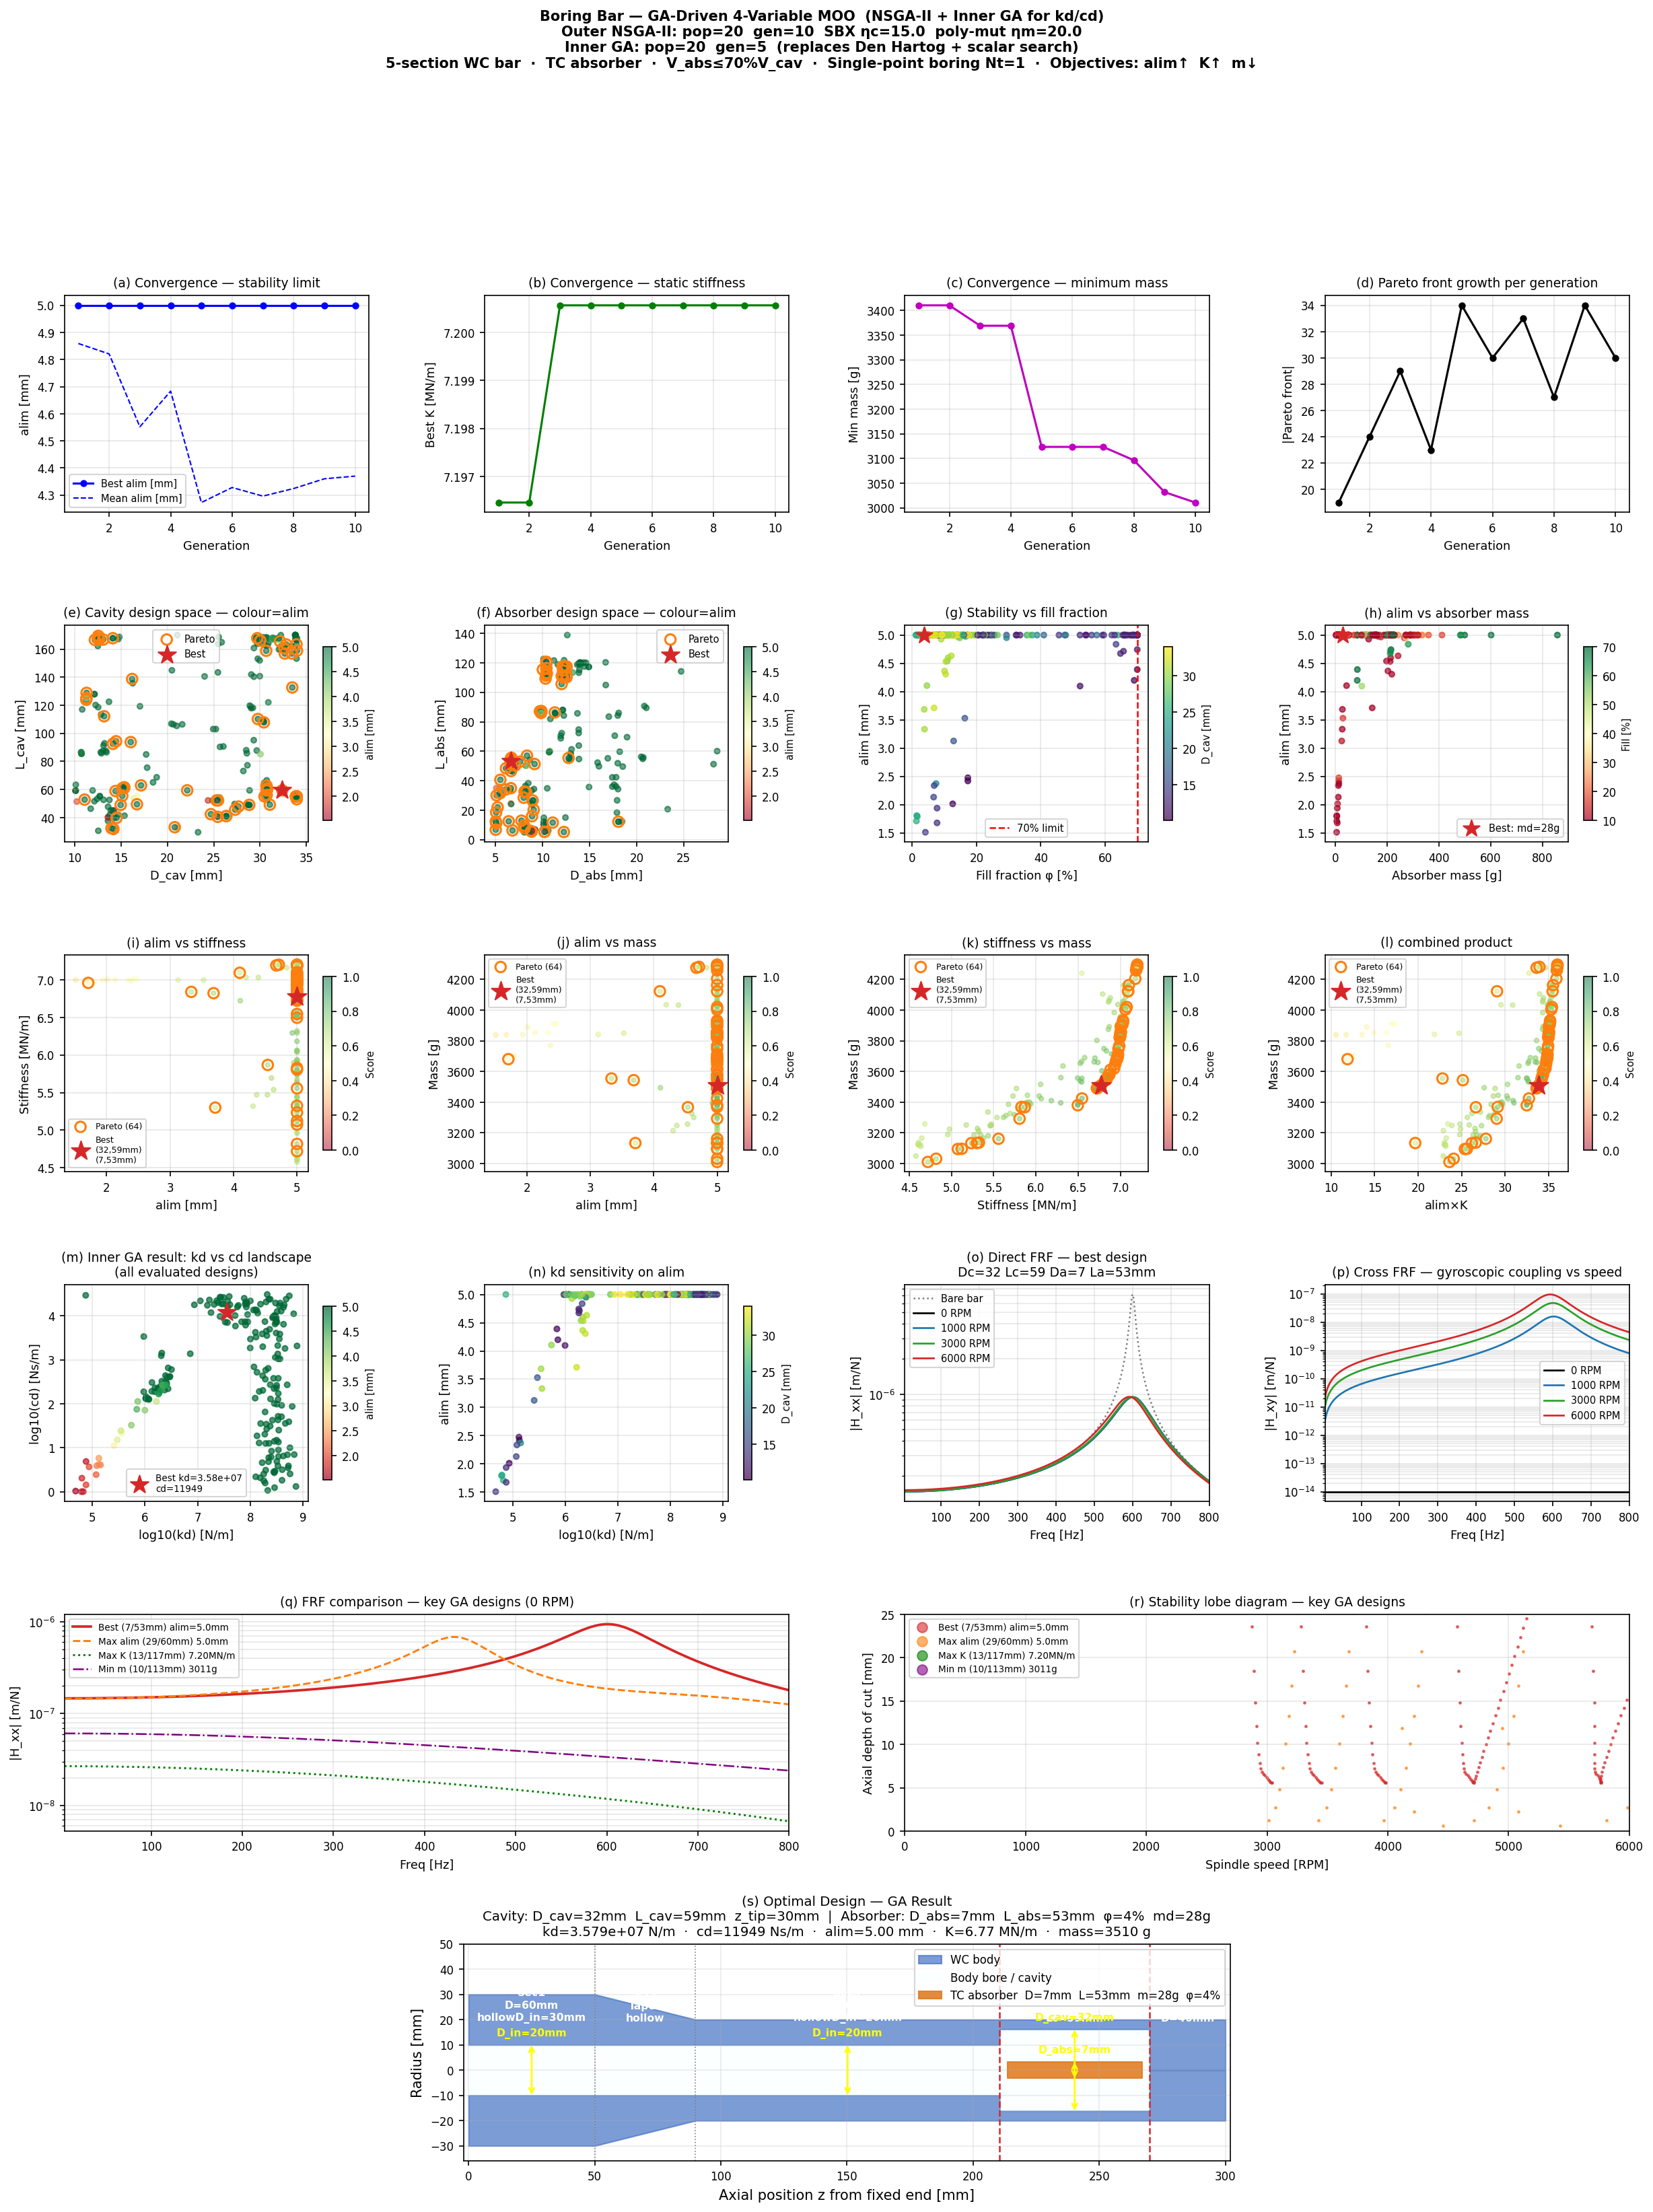


Figure saved → boring_bar_GA_MOO.png


In [ ]:
make_plots(all_results, pareto_front, history)